In [1]:
#Installing all required libraries and dataset

!pip install tensorflow-datasets gradio tensorflow opencv-python matplotlib

In [2]:
!pip install --upgrade protobuf tensorflow-metadata tensorflow-datasets

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 327.1/327.1 kB 4.8 MB/s eta 0:00:00
  Attempting uninstall: protobuf
    Found existing installation: protobuf 5.29.6
    Uninstalling protobuf-5.29.6:
      Successfully uninstalled protobuf-5.29.6
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
ydf 0.15.0 requires protobuf<7.0.0,>=5.29.1, but you have protobuf 7.35.1 which is incompatible.
google-ai-generativelanguage 0.6.15 requires protobuf!=4.21.0,!=4.21.1,!=4.21.2,!=4.21.3,!=4.21.4,!=4.21.5,<6.0.0dev,>=3.20.2, but you have protobuf 7.35.1 which is incompatible.
grpcio-status 1.71.2 requires protobuf<6.0dev,>=5.26.1, but you have protobuf 7.35.1 which is incompatible.


In [1]:
import tensorflow_datasets as tfds
import numpy as np

print("Downloading EMNIST dataset via TensorFlow Datasets...")

# Load the entire dataset into memory at once as NumPy arrays
dataset, info = tfds.load('emnist/byclass', batch_size=-1, as_supervised=True, with_info=True)

train_ds = tfds.as_numpy(dataset['train'])
test_ds = tfds.as_numpy(dataset['test'])

X_train, y_train = train_ds[0], train_ds[1]
X_test, y_test = test_ds[0], test_ds[1]

# Normalize the data (scale pixel values to be between 0 and 1)
X_train = X_train.astype('float32') / 255.0
X_test = X_test.astype('float32') / 255.0

print(f"Training data shape: {X_train.shape}")
print(f"Testing data shape: {X_test.shape}")
print("Dataset successfully loaded! ")

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Extraction completed...: 0 file [00:00, ? file/s]

Extraction completed...: 0 file [00:00, ? file/s]

Generating splits...:   0%|          | 0/2 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/emnist/byclass/incomplete.CQ08KH_3.1.0/emnist-train.tfrecord-[0-9][0-9][0-…

Generating test examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/emnist/byclass/incomplete.CQ08KH_3.1.0/emnist-test.tfrecord-[0-9][0-9][0-9…

Dataset emnist downloaded and prepared to /root/tensorflow_datasets/emnist/byclass/3.1.0. Subsequent calls will reuse this data.
Training data shape: (697932, 28, 28, 1)
Testing data shape: (116323, 28, 28, 1)
Dataset successfully loaded! 


Analyzing the dataset...


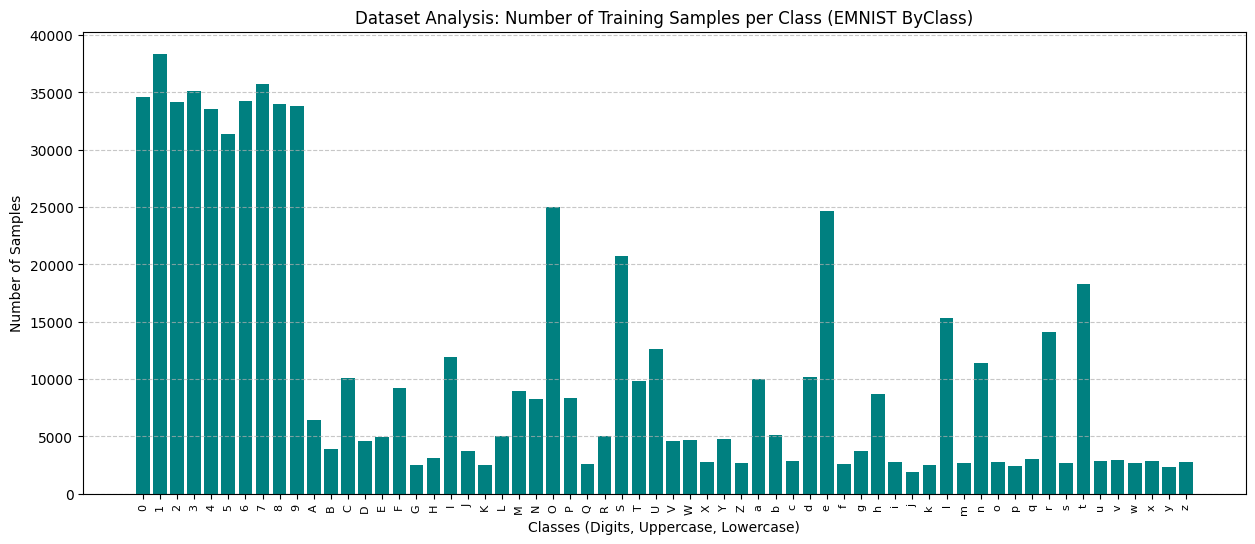

The EMNIST ByClass dataset is highly imbalanced.
Digits and uppercase letters have significantly more samples than lowercase letters.


In [2]:
import matplotlib.pyplot as plt
import numpy as np

print("Analyzing the dataset...")
unique_classes, counts = np.unique(y_train, return_counts=True)

def get_char_label(cls_idx):
    if cls_idx < 10: return str(cls_idx)
    elif cls_idx < 36: return chr(cls_idx - 10 + 65)
    else: return chr(cls_idx - 36 + 97)

labels = [get_char_label(idx) for idx in unique_classes]

# Bar chart
plt.figure(figsize=(15, 6))
plt.bar(labels, counts, color='teal')
plt.title("Dataset Analysis: Number of Training Samples per Class (EMNIST ByClass)")
plt.xlabel("Classes (Digits, Uppercase, Lowercase)")
plt.ylabel("Number of Samples")
plt.xticks(rotation=90, fontsize=8)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

print("The EMNIST ByClass dataset is highly imbalanced.")
print("Digits and uppercase letters have significantly more samples than lowercase letters.")

In [3]:
import tensorflow as tf
from tensorflow.keras import layers, models

print("Preparing data shape...")
# images must have the channel dimension (28, 28, 1) for the CNN
X_train = X_train.reshape(-1, 28, 28, 1)
X_test = X_test.reshape(-1, 28, 28, 1)

print("Building the custom CNN model...")

model = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation='relu'),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),

    #Output layer
    layers.Dense(62, activation='softmax')
])

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

model.summary()

print("\nTraining Starts..")
# Model Training
history = model.fit(X_train, y_train,
                    epochs=5,
                    validation_data=(X_test, y_test),
                    batch_size=256)

model.save('custom_emnist_model.keras')
print("Model successfully trained!")

Preparing data shape...
Building the custom CNN model...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 3, 3, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 576)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 62)             │         7,998 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 137,598 (537.49 KB)

 Trainable params: 137,598 (537.49 KB)

 Non-trainable params: 0 (0.00 B)


Training Starts..
Epoch 1/5
2727/2727 ━━━━━━━━━━━━━━━━━━━━ 549s 201ms/step - accuracy: 0.7907 - loss: 0.6547 - val_accuracy: 0.8495 - val_loss: 0.4174
Epoch 2/5
2727/2727 ━━━━━━━━━━━━━━━━━━━━ 561s 206ms/step - accuracy: 0.8444 - loss: 0.4420 - val_accuracy: 0.8574 - val_loss: 0.3882
Epoch 3/5
2727/2727 ━━━━━━━━━━━━━━━━━━━━ 558s 205ms/step - accuracy: 0.8526 - loss: 0.4112 - val_accuracy: 0.8604 - val_loss: 0.3755
Epoch 4/5
2727/2727 ━━━━━━━━━━━━━━━━━━━━ 533s 196ms/step - accuracy: 0.8575 - loss: 0.3934 - val_accuracy: 0.8612 - val_loss: 0.3707
Epoch 5/5
2727/2727 ━━━━━━━━━━━━━━━━━━━━ 532s 195ms/step - accuracy: 0.8610 - loss: 0.3813 - val_accuracy: 0.8654 - val_loss: 0.3615
Model successfully trained!


Generating Confusion Matrix on Test Data...
3636/3636 ━━━━━━━━━━━━━━━━━━━━ 31s 9ms/step


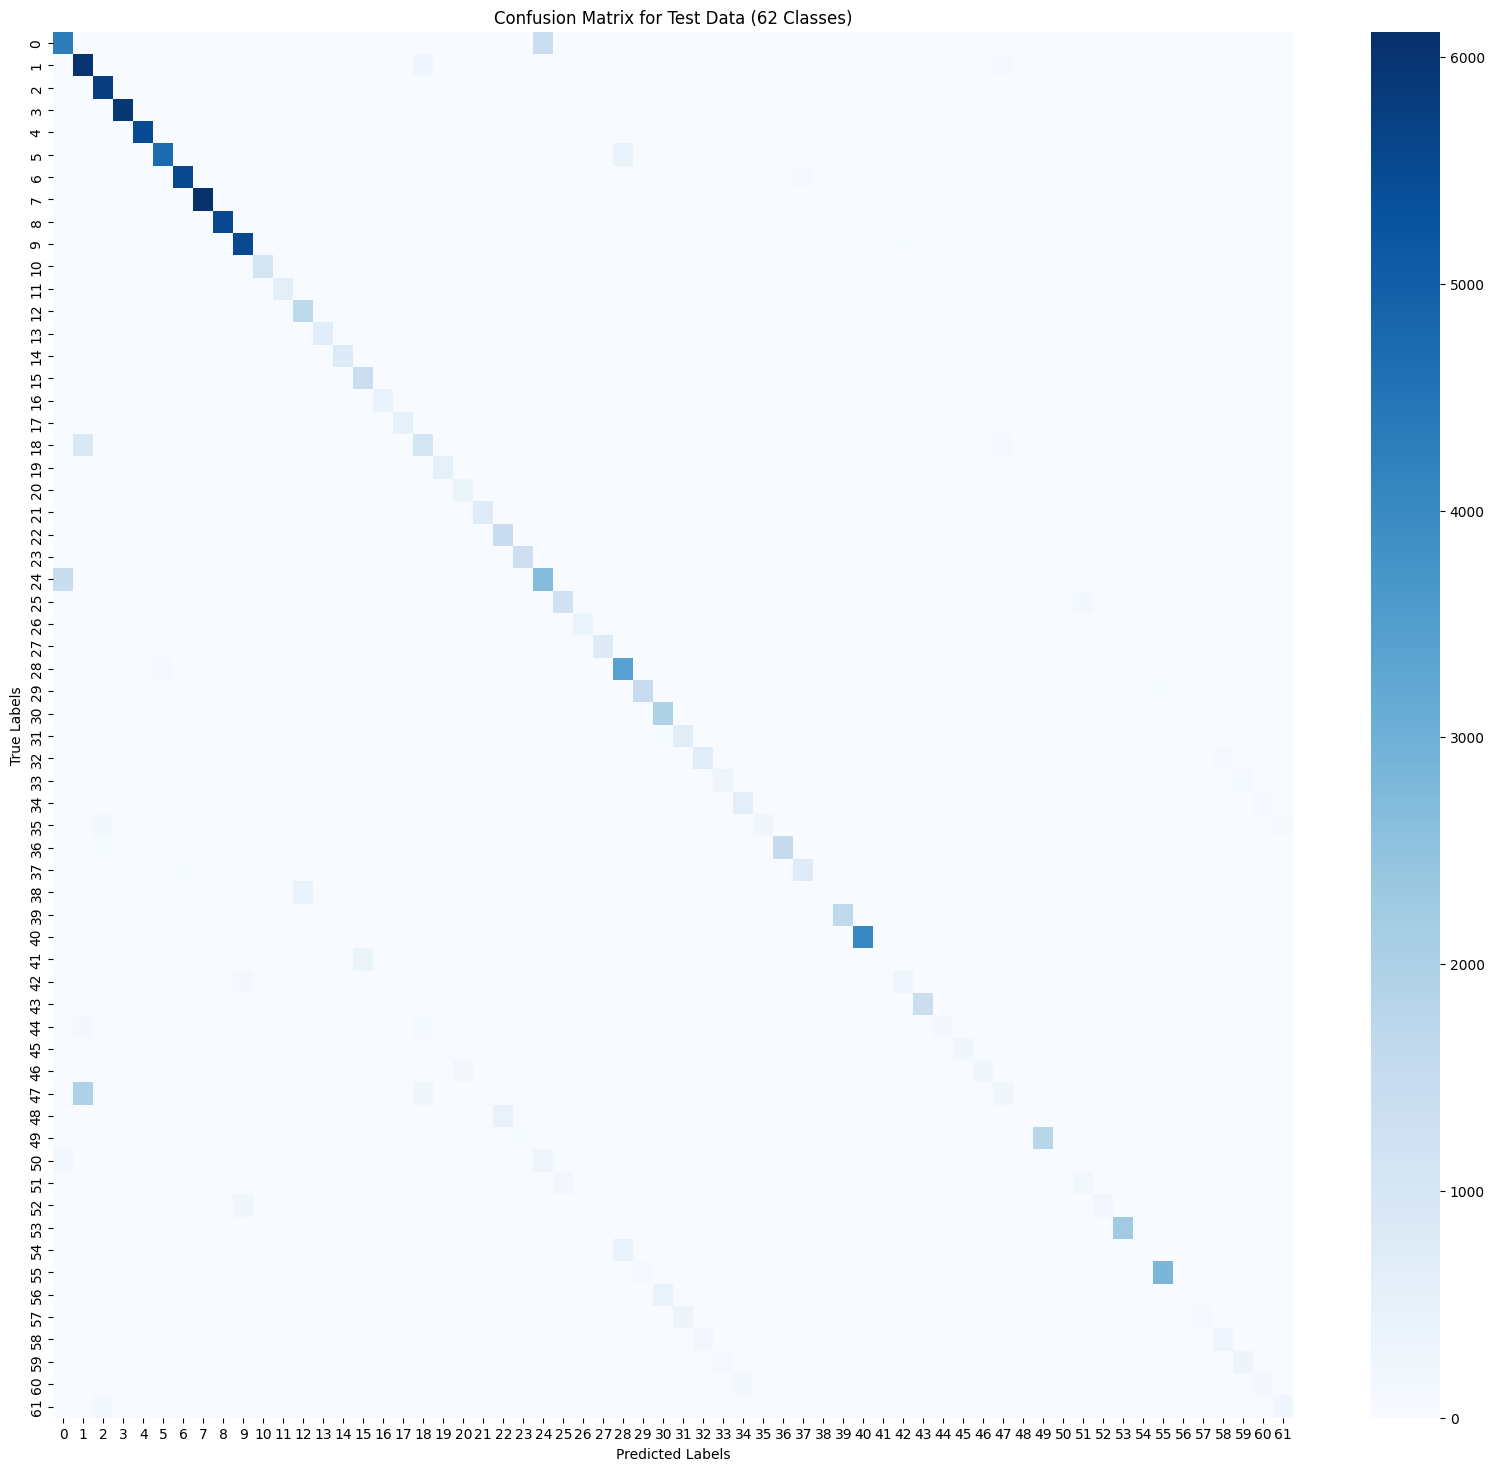


Calculating TP, FP, TN, FN for Each Class...


,Character Class,True Positives (TP),False Positives (FP),True Negatives (TN),False Negatives (FN)
0,0,4307,1701,108844,1471
1,1,6022,3083,106910,308
2,2,5794,426,110028,75
3,3,5936,63,110291,33
4,4,5484,186,110518,135
...,...,...,...,...,...
57,v,102,74,115781,366
58,w,282,84,115772,185
59,x,330,127,115726,140
60,y,136,105,115837,245



Detailed Classification Report
              precision    recall  f1-score   support

           0       0.72      0.75      0.73      5778
           1       0.66      0.95      0.78      6330
           2       0.93      0.99      0.96      5869
           3       0.99      0.99      0.99      5969
           4       0.97      0.98      0.97      5619
           5       0.97      0.91      0.94      5190
           6       0.98      0.97      0.97      5705
           7       0.98      1.00      0.99      6139
           8       0.98      0.99      0.98      5633
           9       0.93      0.97      0.95      5686
           A       0.94      0.97      0.96      1062
           B       0.94      0.93      0.93       648
           C       0.76      0.97      0.85      1739
           D       0.90      0.92      0.91       779
           E       0.96      0.94      0.95       851
           F       0.77      0.97      0.86      1440
           G       0.95      0.85      0.90      

In [6]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

print("Generating Confusion Matrix on Test Data...")

y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)

cm = confusion_matrix(y_test, y_pred)

# Heatmap
plt.figure(figsize=(20, 18))
sns.heatmap(cm, annot=False, cmap='Blues', fmt='g')
plt.title("Confusion Matrix for Test Data (62 Classes)")
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.show()

print("\n" + "="*50)
print("Calculating TP, FP, TN, FN for Each Class...")
print("="*50)

# For Multi-class,calculating TP, FP, FN, TN
TP = np.diag(cm)
FP = cm.sum(axis=0) - TP
FN = cm.sum(axis=1) - TP
TN = cm.sum() - (FP + FN + TP)

# generate Labels  (0-9, A-Z, a-z)
def get_char_label(cls_idx):
    if cls_idx < 10: return str(cls_idx)
    elif cls_idx < 36: return chr(cls_idx - 10 + 65)
    else: return chr(cls_idx - 36 + 97)

class_names = [get_char_label(i) for i in range(62)]

metrics_df = pd.DataFrame({
    'Character Class': class_names,
    'True Positives (TP)': TP,
    'False Positives (FP)': FP,
    'True Negatives (TN)': TN,
    'False Negatives (FN)': FN
})

display(metrics_df)

print("\n" + "="*50)
print("Detailed Classification Report")
print("="*50)
print(classification_report(y_test, y_pred, target_names=class_names))

In [5]:
!pip install --upgrade gradio fastapi pydantic uvicorn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 130.3/130.3 kB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.7/72.7 kB 6.3 MB/s eta 0:00:00
  Attempting uninstall: uvicorn
    Found existing installation: uvicorn 0.49.0
    Uninstalling uvicorn-0.49.0:
      Successfully uninstalled uvicorn-0.49.0
  Attempting uninstall: fastapi
    Found existing installation: fastapi 0.138.0
    Uninstalling fastapi-0.138.0:
      Successfully uninstalled fastapi-0.138.0


In [ ]:
import tensorflow as tf
import gradio as gr
import cv2
import numpy as np

print("Loading Model into memory...")
model = tf.keras.models.load_model('custom_emnist_model.keras')
print("Model successfully loaded!")

def get_character_mapping():
    mapping = {}
    for i in range(10): mapping[i] = str(i)
    for i in range(26): mapping[i + 10] = chr(i + 65)
    for i in range(26): mapping[i + 36] = chr(i + 97)
    return mapping

class_mapping = get_character_mapping()

def predict_drawing(image):
    if image is None:
        return "Please draw something!"

    if isinstance(image, dict):
        img_array = image['composite']
    else:
        img_array = image

    if len(img_array.shape) == 3:
        gray = cv2.cvtColor(img_array, cv2.COLOR_BGR2GRAY)
    else:
        gray = img_array

    if np.mean(gray) > 127:
        gray = cv2.bitwise_not(gray)

    resized = cv2.resize(gray, (28, 28), interpolation=cv2.INTER_AREA)

    rotated = cv2.rotate(resized, cv2.ROTATE_90_CLOCKWISE)
    flipped = cv2.flip(rotated, 1)

    normalized = flipped.astype('float32') / 255.0
    final_input = normalized.reshape(1, 28, 28, 1)

    # Use model for predictions
    predictions = model.predict(final_input)
    predicted_class = np.argmax(predictions)
    confidence = np.max(predictions) * 100

    predicted_char = class_mapping[predicted_class]

    return f"Prediction: '{predicted_char}' (Confidence: {confidence:.2f}%)"

# Gradio Interface Setup
demo = gr.Interface(
    fn=predict_drawing,
    inputs=gr.Sketchpad(type="numpy"),
    outputs="text",
    title="EMNIST AI Recognizer",
    description="Draw any number,small or capital shape on the canva and click on submit!"
)

demo.launch(debug=True)

Loading Model into memory...
Model successfully loaded!
It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://a41d89ab20c6aa4c67.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


/usr/local/lib/python3.12/dist-packages/gradio/routes.py:1379: StarletteDeprecationWarning: 'HTTP_422_UNPROCESSABLE_ENTITY' is deprecated. Use 'HTTP_422_UNPROCESSABLE_CONTENT' instead.
  return await queue_join_helper(body, request, username)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 118ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step


/usr/local/lib/python3.12/dist-packages/gradio/routes.py:1379: StarletteDeprecationWarning: 'HTTP_422_UNPROCESSABLE_ENTITY' is deprecated. Use 'HTTP_422_UNPROCESSABLE_CONTENT' instead.
  return await queue_join_helper(body, request, username)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step


...

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step


/usr/local/lib/python3.12/dist-packages/gradio/routes.py:1379: StarletteDeprecationWarning: 'HTTP_422_UNPROCESSABLE_ENTITY' is deprecated. Use 'HTTP_422_UNPROCESSABLE_CONTENT' instead.
  return await queue_join_helper(body, request, username)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step


/usr/local/lib/python3.12/dist-packages/gradio/routes.py:1379: StarletteDeprecationWarning: 'HTTP_422_UNPROCESSABLE_ENTITY' is deprecated. Use 'HTTP_422_UNPROCESSABLE_CONTENT' instead.
  return await queue_join_helper(body, request, username)
/usr/local/lib/python3.12/dist-packages/gradio/routes.py:1379: StarletteDeprecationWarning: 'HTTP_422_UNPROCESSABLE_ENTITY' is deprecated. Use 'HTTP_422_UNPROCESSABLE_CONTENT' instead.
  return await queue_join_helper(body, request, username)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
